# Previsão da temperatura da água do mar — dataset CalCOFI

**Disciplina:** Machine Learning · **Tipo de problema:** Regressão supervisionada
**Dataset:** [CalCOFI — Over 60 years of oceanographic data](https://www.kaggle.com/datasets/sohier/calcofi) (Kaggle, arquivos `bottle.csv` e `cast.csv`)

## 1. O problema

O CalCOFI (*California Cooperative Oceanic Fisheries Investigations*) mede o oceano na costa da Califórnia desde 1949.
Um navio para numa **estação** (um ponto no mar) e mede a água em várias **profundidades**: temperatura, salinidade,
oxigênio, nutrientes etc.

### A pergunta de previsão

A pergunta sugerida para esta base é:

> **Dá para prever a temperatura da água a partir da salinidade?**

Vamos responder a essa pergunta e depois ampliá-la:

> **Quais medições da água permitem prever a temperatura, e qual modelo faz isso melhor?**

- **Variável-alvo (y):** temperatura da água, `T_degC`, em °C → número contínuo → **problema de regressão**.
- **Variáveis preditoras (X):** as demais medições da água e informações da estação (local e data).

### Como o trabalho está organizado

1. **Preparação** (seções 2 a 8): carga, recorte, limpeza com critério, análise exploratória e divisão treino/teste.
2. **Parte A — Modelos lineares** (seção 9): do mais simples ao mais completo, com testes estatísticos e seleção de variáveis.
3. **Parte B — Modelos não lineares** (seção 10): KNN, Random Forest e Gradient Boosting, com seleção de variáveis e ajuste de hiperparâmetros.
4. **Comparação, robustez e modelo final** (seções 11 a 16).

Cada modelo responde a uma pergunta. Ferramentas que **não trouxeram ganho** também são mostradas, com o motivo de terem sido descartadas.

### Métricas

- **R² (coeficiente de determinação):** fração da variação da temperatura que o modelo explica.
  R² = 0 equivale a chutar sempre a média; R² = 1 é acerto perfeito.

  $$R^2 = 1 - \frac{\sum (y_i - \hat y_i)^2}{\sum (y_i - \bar y)^2} = 1 - \frac{\text{erro do modelo}}{\text{erro de chutar a média}}$$

- **R² ajustado (métrica principal):** o R² comum **nunca diminui** quando colocamos mais variáveis, mesmo inúteis.
  O R² ajustado **penaliza** cada variável extra. É a métrica certa para **comparar modelos com números diferentes de variáveis**:

  $$R^2_{aj} = 1 - (1 - R^2)\,\frac{n - 1}{n - p - 1}$$

  em que $n$ é o número de observações e $p$ o número de variáveis.

- **MAE** (erro absoluto médio, em °C): "em média o modelo erra X graus". **RMSE**: parecido, mas pune mais os erros grandes.

### Critério de escolha do modelo final (definido antes de modelar)

1. A escolha usa o **R² da validação cruzada** (calculado só no treino), e não o do teste, para que o teste continue sendo uma
   avaliação independente.
2. **Parcimônia:** entre modelos cujo R² fica a no máximo **0,005** do melhor, preferimos o **mais simples** (menos variáveis).
   Um modelo mais simples é mais fácil de explicar, depende de menos medições e tende a generalizar melhor.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV, lasso_path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

SEED = 42  # semente fixa: o resultado é o mesmo toda vez que o notebook roda
AZUL, LARANJA, CINZA, VERDE = "#2563eb", "#ea580c", "#9ca3af", "#16a34a"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
FIGURAS = Path("figuras")
FIGURAS.mkdir(exist_ok=True)

## 2. Carga dos dados

O dataset tem dois arquivos que se complementam:

| Arquivo | Uma linha é… | O que tem |
|---|---|---|
| `bottle.csv` | uma **medição** (uma profundidade numa estação) | temperatura, salinidade, oxigênio, nutrientes… |
| `cast.csv` | uma **estação** (a parada do navio) | data, latitude, longitude, profundidade do fundo… |

Eles se ligam pela coluna `Cst_Cnt` (o número da estação). Se os arquivos não estiverem em `data/`, a célula baixa do Kaggle com `kagglehub`.

In [2]:
PASTA = Path("data")
if not (PASTA / "bottle.csv").exists():
    import kagglehub, shutil
    origem = Path(kagglehub.dataset_download("sohier/calcofi"))
    PASTA.mkdir(exist_ok=True)
    for arquivo in ["bottle.csv", "cast.csv"]:
        shutil.copy(origem / arquivo, PASTA / arquivo)

bottle = pd.read_csv(PASTA / "bottle.csv", encoding="latin1", low_memory=False)
cast = pd.read_csv(PASTA / "cast.csv", encoding="latin1", low_memory=False)
print(f"bottle.csv: {bottle.shape[0]:,} linhas x {bottle.shape[1]} colunas")
print(f"cast.csv:   {cast.shape[0]:,} linhas x {cast.shape[1]} colunas")

# Do cast.csv trazemos só o que pode ajudar a explicar a temperatura: data, posição, profundidade do fundo e distância da costa
INFO_ESTACAO = ["Cst_Cnt", "Year", "Month", "Lat_Dec", "Lon_Dec", "Bottom_D", "Distance"]
df_completo = bottle.merge(cast[INFO_ESTACAO], on="Cst_Cnt", how="left")
print(f"Base unida: {df_completo.shape[0]:,} linhas x {df_completo.shape[1]} colunas")
df_completo[["Cst_Cnt", "Year", "Depthm", "T_degC", "Salnty", "O2ml_L", "NO3uM", "Lat_Dec", "Lon_Dec"]].head()

bottle.csv: 864,863 linhas x 74 colunas
cast.csv:   34,404 linhas x 61 colunas
Base unida: 864,863 linhas x 80 colunas


,Cst_Cnt,Year,Depthm,T_degC,Salnty,O2ml_L,NO3uM,Lat_Dec,Lon_Dec
0,1,1949,0,10.50,33.440,NaN,NaN,38.833333,-124.083333
1,1,1949,8,10.46,33.440,NaN,NaN,38.833333,-124.083333
2,1,1949,10,10.46,33.437,NaN,NaN,38.833333,-124.083333
3,1,1949,19,10.45,33.420,NaN,NaN,38.833333,-124.083333
4,1,1949,20,10.45,33.421,NaN,NaN,38.833333,-124.083333


## 3. Recorte do período: 2005 a 2016

A base completa tem **mais de 860 mil medições, de 1949 a 2016**. Usamos **todas** as medições do período **2005–2016**:

1. **Medições completas.** Nas décadas antigas os nutrientes quase nunca eram medidos (ver abaixo). Essas linhas seriam descartadas na limpeza de qualquer jeito.
2. **Coerência.** O oceano esquentou e os instrumentos mudaram em 70 anos. Um período recente deixa o modelo coerente com o presente.
3. **Tamanho e tempo de execução.** Com ~97 mil medições o notebook roda em poucos minutos.

Isto **não é amostragem aleatória**: é uma decisão de escopo, e usamos todas as medições do período escolhido.

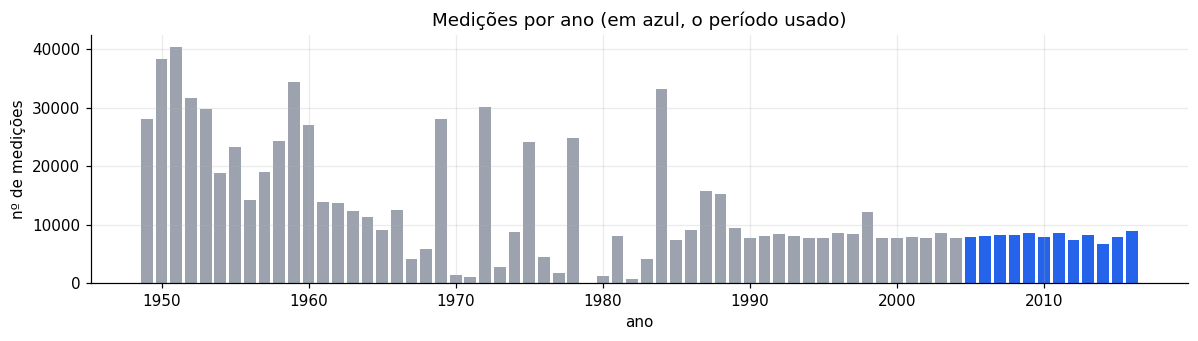

Linhas com os 4 nutrientes medidos — antes de 2005: 31% | 2005 em diante: 92%
Período 2005-2016: 96,655 medições em 3,682 estações, 80 colunas


In [3]:
NUTRIENTES = ["PO4uM", "SiO3uM", "NO3uM", "NO2uM"]
com_nutrientes = df_completo[NUTRIENTES].notna().all(axis=1)
antes = df_completo["Year"] < 2005

por_ano = df_completo.groupby("Year").size()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(por_ano.index, por_ano.values, color=[AZUL if a >= 2005 else CINZA for a in por_ano.index], width=0.8)
ax.set(title="Medições por ano (em azul, o período usado)", xlabel="ano", ylabel="nº de medições")
plt.tight_layout(); plt.savefig(FIGURAS / "medicoes_por_ano.png", bbox_inches="tight"); plt.show()

print(f"Linhas com os 4 nutrientes medidos — antes de 2005: {com_nutrientes[antes].mean():.0%} | 2005 em diante: {com_nutrientes[~antes].mean():.0%}")
df = df_completo[~antes].copy()
print(f"Período 2005-2016: {len(df):,} medições em {df['Cst_Cnt'].nunique():,} estações, {df.shape[1]} colunas")

## 4. Conhecendo as colunas

As 80 colunas se dividem em poucos grupos. Entender os grupos é o que permite limpar a base com critério:

| Grupo | Exemplos | O que fazer |
|---|---|---|
| **Medições da água** | `T_degC` (temperatura), `Salnty`, `O2ml_L`, `Depthm`, nutrientes | Candidatas a preditoras |
| **Informações da estação** | `Year`, `Month`, `Lat_Dec`, `Lon_Dec`, `Bottom_D`, `Distance` | Candidatas a preditoras |
| **Identificadores** | `Cst_Cnt`, `Btl_Cnt`, `Sta_ID`, `Depth_ID` | Códigos sem significado físico |
| **Qualidade / precisão** | `T_qual`, `S_prec`, `O2Satq`, `PO4q`… | Descrevem a medição, não a água |
| **Valores "reportados" (`R_…`)** | `R_SALINITY`, `R_O2`, `R_PO4`… | Cópias arredondadas das medições |
| **Calculadas a partir da temperatura** | `R_TEMP`, `R_POTEMP`, `STheta`, `R_SIGMA`, `O2Sat`… | **Vazamento de dados** (seção 6) |

In [4]:
ausentes = (df.isna().mean() * 100).round(1).sort_values()
print("Colunas com menos de 30% de ausentes:", (ausentes < 30).sum(), "| com 30% ou mais:", (ausentes >= 30).sum())
ausentes.to_frame("% ausentes").T

Colunas com menos de 30% de ausentes: 42 | com 30% ou mais: 38


,Cst_Cnt,R_TEMP,R_POTEMP,R_SALINITY,R_SVA,S_prec,R_DYNHT,T_prec,RecInd,R_Depth,R_PRES,Month,Lat_Dec,Lon_Dec,Salnty,T_degC,Depthm,Depth_ID,Sta_ID,Btl_Cnt,Year,R_SIGMA,Bottom_D,Distance,STheta,R_O2,R_O2Sat,O2ml_L,Oxy_Âµmol/Kg,O2Sat,C14A1q,C14A2q,R_SIO3,R_NO3,NO3uM,SiO3uM,R_PO4,PO4uM,NO2uM,R_NO2,DarkAq,MeanAq,R_SAMP,R_PHAEO,R_CHLA,ChlorA,Phaeop,NH3uM,R_NH4,BtlNum,NH3q,Chlqua,Phaqua,S_qual,O_qual,P_qual,O2Satq,SThtaq,T_qual,NO2q,NO3q,PO4q,SiO3qu,MeanAs,DarkAs,IncTim,C14As2,C14As1,MeanAp,DarkAp,C14A2p,C14A1p,LightP,TA1,DIC1,TA2,DIC2,DIC Quality Comment,pH1,pH2
% ausentes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.1,1.1,3.0,3.0,3.0,3.1,3.1,7.0,7.0,7.5,7.5,7.5,7.5,7.7,7.7,7.8,7.8,9.1,9.1,30.0,32.7,32.7,32.7,32.8,32.8,32.8,33.5,58.5,67.8,67.8,73.9,82.0,83.0,85.0,87.6,88.2,90.0,90.2,92.3,92.5,92.7,92.7,94.9,94.9,94.9,95.0,95.0,96.7,96.7,96.9,97.8,97.9,99.8,99.8,99.9,99.9,100.0


## 5. Variável-alvo e relação com as demais

A temperatura é o alvo natural: é a pergunta da base, quase não tem ausentes e é contínua.

Usamos a correlação de **Spearman** (e não a de Pearson) porque ela mede se duas variáveis "sobem e descem juntas"
**mesmo quando a relação é uma curva**, e é robusta a outliers. No oceano esperamos relações curvas.

In [5]:
MEDICOES = ["T_degC", "Salnty", "Depthm", "O2ml_L", "PO4uM", "SiO3uM", "NO3uM", "NO2uM", "Lat_Dec", "Lon_Dec", "Bottom_D", "Distance", "Month", "Year"]
correlacao = df[MEDICOES].corr(method="spearman")["T_degC"].drop("T_degC").sort_values(key=abs, ascending=False)
correlacao.round(2).to_frame("Spearman com T_degC").T

,NO3uM,SiO3uM,PO4uM,Depthm,O2ml_L,Salnty,NO2uM,Lat_Dec,Bottom_D,Month,Lon_Dec,Year,Distance
Spearman com T_degC,-0.98,-0.97,-0.97,-0.93,0.91,-0.85,0.3,-0.06,-0.06,0.05,0.04,0.03,0.01


**Interpretação.**

- **Profundidade, nutrientes e oxigênio** têm correlação muito forte com a temperatura (|ρ| > 0,9), e isso tem explicação física:
  - quanto mais **fundo**, mais **fria** a água (o sol só aquece a superfície);
  - a água funda é rica em **nutrientes** porque lá não há luz nem algas para consumi-los;
  - a água da superfície tem mais **oxigênio** (contato com o ar e fotossíntese das algas).
- A **salinidade** também é forte (ρ ≈ −0,85): as águas profundas da Califórnia são mais salgadas.
- **Localização e data** quase não se relacionam com a temperatura *sozinhas*, mas podem ajudar combinadas com as outras.

**A ideia central do trabalho:** o oceano é organizado em **camadas**, e cada camada tem uma "assinatura química"
(sal, oxigênio, nutrientes). Se o modelo aprender a ler essa assinatura, ele descobre a temperatura.

## 6. Limpeza — colunas

### 6.1 Vazamento de dados (*data leakage*)

**Vazamento** é quando o modelo recebe, numa variável, uma informação que já contém a resposta. É como dar o
gabarito ao aluno: a nota sobe, mas ele não aprendeu nada, e o modelo não funcionaria na prática.

Estas colunas são **calculadas a partir da própria temperatura**:

| Coluna | O que é | Por que é vazamento |
|---|---|---|
| `R_TEMP`, `R_POTEMP` | Temperatura reportada / temperatura potencial | É a própria resposta |
| `STheta`, `R_SIGMA` | Densidade da água | Calculada com temperatura **e** salinidade |
| `R_SVA`, `R_DYNHT` | Anomalia de volume e altura dinâmica | Calculadas a partir da densidade |
| `O2Sat`, `R_O2Sat` | Saturação de oxigênio (%) | O oxigênio "máximo" depende da temperatura |
| `Oxy_µmol/Kg` | Oxigênio em outra unidade | A conversão usa a densidade |

A célula abaixo mostra o efeito: o mesmo modelo, com e sem a densidade.

In [6]:
amostra = df[["T_degC", "Salnty", "STheta"]].dropna().sample(frac=1, random_state=SEED)
metade = len(amostra) // 2
treino_demo, teste_demo = amostra.iloc[:metade], amostra.iloc[metade:]
for colunas in (["Salnty"], ["Salnty", "STheta"]):
    demo = HistGradientBoostingRegressor(random_state=SEED).fit(treino_demo[colunas], treino_demo["T_degC"])
    print(f"R² com {colunas}: {demo.score(teste_demo[colunas], teste_demo['T_degC']):.3f}")
print(f"\nCorrelação entre T_degC e R_TEMP: {df['T_degC'].corr(df['R_TEMP']):.4f}  (é a mesma coluna)")

R² com ['Salnty']: 0.695


R² com ['Salnty', 'STheta']: 0.999

Correlação entre T_degC e R_TEMP: 1.0000  (é a mesma coluna)


Só com a salinidade, R² ≈ 0,70. Com a densidade, **0,999**. O modelo não ficou genial: ele só "desfez a conta",
porque a densidade é calculada **com** a temperatura. Essas colunas saem.

### 6.2 Demais colunas removidas

1. **Identificadores** (`Btl_Cnt`, `Sta_ID`…): códigos. (`Cst_Cnt` é guardado à parte para dividir treino e teste por estação.)
2. **Qualidade e precisão** (`*_qual`, `*_prec`, `*q`…): descrevem a medição, não a água.
3. **Cópias `R_…`** de medições que já temos.
4. **Colunas com 30% ou mais de ausentes**: clorofila, feopigmentos e amônia (`ChlorA`, `Phaeop`, `NH3uM`) faltam em ~1/3 das linhas.
   Mantê-las obrigaria a descartar 1/3 da base. Outras colunas (carbono, pH, produtividade) faltam em mais de 90%.

In [7]:
ALVO = "T_degC"
ORIGINAIS = [
    "Salnty", "Depthm", "O2ml_L",                    # medições físicas
    "PO4uM", "SiO3uM", "NO3uM", "NO2uM",             # nutrientes
    "Lat_Dec", "Lon_Dec", "Bottom_D", "Distance",    # localização da estação
    "Month", "Year",                                 # data
]
VAZAMENTO = ["R_TEMP", "R_POTEMP", "STheta", "R_SIGMA", "R_SVA", "R_DYNHT", "O2Sat", "R_O2Sat"] + [c for c in df.columns if c.startswith("Oxy")]
removidas = [c for c in df.columns if c not in ORIGINAIS + [ALVO]]
print(f"Colunas: {df.shape[1]} -> {len(ORIGINAIS)} preditoras + o alvo ({len(removidas)} removidas, {len(VAZAMENTO)} delas por vazamento)")

Colunas: 80 -> 13 preditoras + o alvo (66 removidas, 9 delas por vazamento)


## 7. Limpeza — linhas

| Etapa | Motivo |
|---|---|
| **Duplicatas** | Uma linha repetida poderia cair no treino e no teste: o modelo "veria a resposta" |
| **Valores ausentes** | Não dá para inventar o alvo; e preencher nutrientes com média criaria valores falsos justamente nas variáveis mais importantes. Como os nutrientes faltam juntos, em estações inteiras, e sobram ~88 mil linhas, descartar é seguro |
| **Valores fisicamente impossíveis** | Concentrações negativas (de oxigênio ou nutrientes) não existem: são erros de registro |

Os **outliers extremos** (valores possíveis, mas raros) são tratados **depois** da divisão treino/teste (seção 8),
com limites calculados só no treino, para que o conjunto de teste não influencie nenhuma decisão.

In [8]:
dados = df[["Cst_Cnt", ALVO] + ORIGINAIS]
print(f"Início:                       {len(dados):,}")
dados = dados.drop_duplicates(subset=[ALVO] + ORIGINAIS)
print(f"Após remover duplicatas:      {len(dados):,}")
dados = dados.dropna()
print(f"Após remover ausentes:        {len(dados):,}")
CONCENTRACOES = ["O2ml_L", "PO4uM", "SiO3uM", "NO3uM", "NO2uM"]
dados = dados[(dados[CONCENTRACOES] >= 0).all(axis=1)]
print(f"Após remover impossíveis:     {len(dados):,}  ({dados['Cst_Cnt'].nunique():,} estações)")

Início:                       96,655
Após remover duplicatas:      96,634
Após remover ausentes:        88,773
Após remover impossíveis:     88,772  (3,493 estações)


### 7.1 Análise exploratória

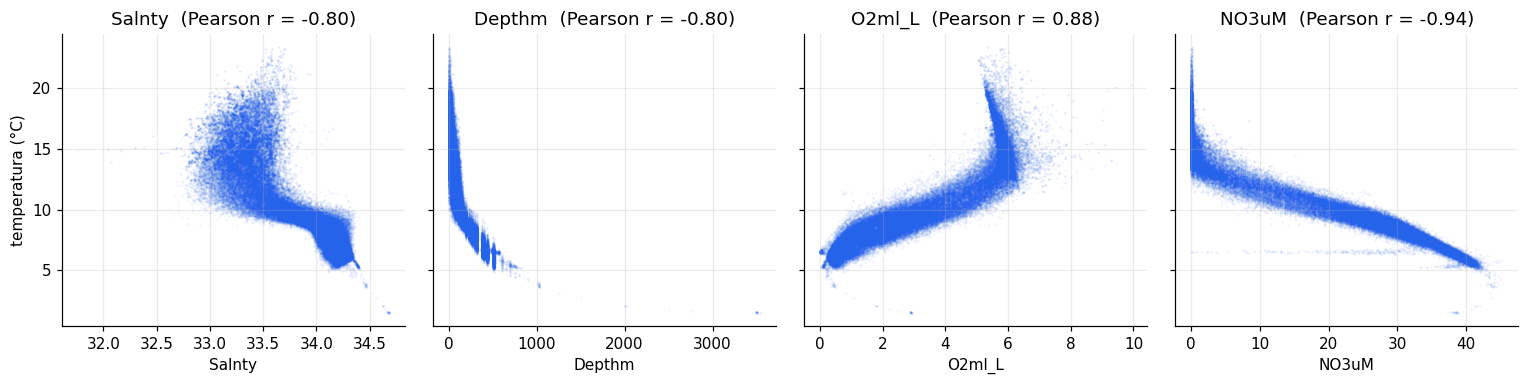

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
for ax, col in zip(axes, ["Salnty", "Depthm", "O2ml_L", "NO3uM"]):
    ax.scatter(dados[col], dados[ALVO], s=2, alpha=0.08, color=AZUL, linewidths=0)
    ax.set(title=f"{col}  (Pearson r = {dados[col].corr(dados[ALVO]):.2f})", xlabel=col)
axes[0].set_ylabel("temperatura (°C)")
plt.tight_layout(); plt.savefig(FIGURAS / "dispersao_variaveis.png", bbox_inches="tight"); plt.show()

**Interpretação.**

- **Salinidade:** há relação (água mais salgada tende a ser mais fria), mas a nuvem é larga: para a mesma salinidade há
  temperaturas muito diferentes. Já indica que **só a salinidade não vai bastar**.
- **Profundidade:** a temperatura cai rápido nos primeiros ~200 m e depois quase não muda. É uma **curva** (a *termoclina*),
  não uma reta. Um modelo linear terá dificuldade; uma **transformação logarítmica** da profundidade ou um modelo não linear devem ajudar.
- **Oxigênio e nitrato:** relações fortes e "apertadas", mas também curvas nas pontas.

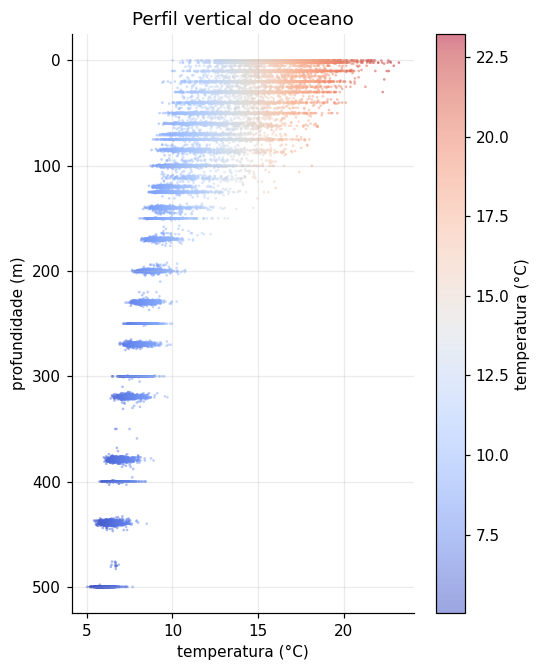

In [10]:
# Perfil vertical: temperatura x profundidade (amostra de 20 mil medições até 500 m, só para o gráfico ficar legível)
perfil = dados[dados["Depthm"] <= 500].sample(20_000, random_state=SEED)
fig, ax = plt.subplots(figsize=(5, 6.2))
pontos = ax.scatter(perfil[ALVO], perfil["Depthm"], c=perfil[ALVO], cmap="coolwarm", s=3, alpha=0.5, linewidths=0)
ax.invert_yaxis()
ax.set(title="Perfil vertical do oceano", xlabel="temperatura (°C)", ylabel="profundidade (m)")
fig.colorbar(pontos, ax=ax, label="temperatura (°C)")
plt.tight_layout(); plt.savefig(FIGURAS / "perfil_temperatura.png", bbox_inches="tight"); plt.show()

**Interpretação.** O mesmo dado visto como um oceano "de pé": a temperatura cai rapidamente nos primeiros ~200 m
(a **termoclina**) e quase não muda abaixo disso. É essa curva que os modelos lineares terão dificuldade de representar.

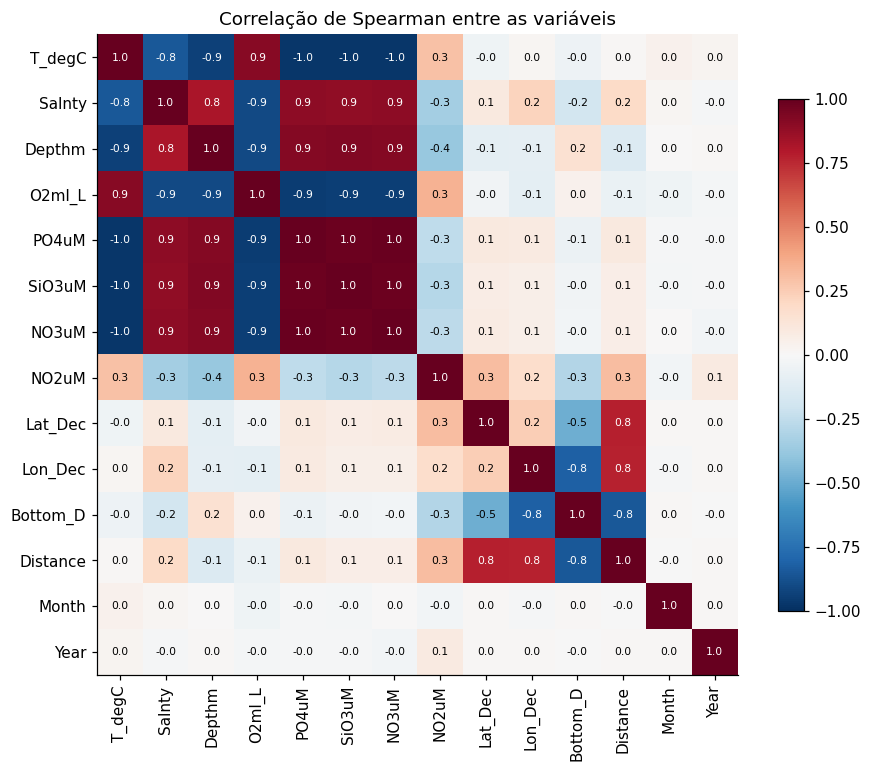

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 7))
corr = dados[[ALVO] + ORIGINAIS].corr(method="spearman")
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90); ax.set_yticks(range(len(corr)), corr.columns); ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.1f}", ha="center", va="center", fontsize=7, color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8); ax.set_title("Correlação de Spearman entre as variáveis")
plt.tight_layout(); plt.savefig(FIGURAS / "mapa_correlacao.png", bbox_inches="tight"); plt.show()

**Interpretação.** O bloco vermelho/azul forte no canto superior mostra que temperatura, profundidade, oxigênio e
nutrientes estão **todos fortemente correlacionados entre si**, não só com a temperatura. Isso se chama
**multicolinearidade**, medida a seguir pelo **VIF** (*Variance Inflation Factor*): quanto a variância do coeficiente de uma
variável é "inflada" porque ela pode ser prevista pelas outras. Regra prática: **VIF > 10 indica problema**.

In [12]:
X_vif = sm.add_constant(dados[ORIGINAIS])
vif = pd.Series([variance_inflation_factor(X_vif.values, i + 1) for i in range(len(ORIGINAIS))], index=ORIGINAIS)
vif.sort_values(ascending=False).round(1).to_frame("VIF").T

,PO4uM,Distance,NO3uM,O2ml_L,SiO3uM,Lat_Dec,Lon_Dec,Depthm,Salnty,Bottom_D,NO2uM,Month,Year
VIF,130.3,74.2,68.9,43.1,37.1,34.1,30.4,11.6,9.3,4.5,1.4,1.0,1.0


**Interpretação.** Fosfato (130), distância da costa (74), nitrato (69), oxigênio (43), silicato (37), latitude (34), longitude (30) e profundidade (12) passam de 10: carregam quase a mesma informação. (A distância da costa é praticamente uma conta feita com latitude e longitude.) A multicolinearidade **não atrapalha a previsão**, mas deixa os coeficientes da regressão
linear instáveis e difíceis de interpretar, o que motiva a **seleção de variáveis** mais adiante.

## 8. Engenharia de atributos e divisão treino/teste

### 8.1 Engenharia de atributos

Criamos três variáveis novas a partir das existentes:

| Nova variável | Como | Por quê |
|---|---|---|
| `log_prof` | $\log(1 + \text{profundidade})$ | A temperatura cai rápido perto da superfície e devagar no fundo. O log "estica" os primeiros metros e "comprime" o fundo, deixando a relação mais próxima de uma reta |
| `mes_sin`, `mes_cos` | $\sin(2\pi \cdot \text{mês}/12)$, $\cos(2\pi \cdot \text{mês}/12)$ | O mês é **cíclico**: dezembro (12) e janeiro (1) são vizinhos, mas como número ficam longe. Seno e cosseno colocam os meses num círculo |

Essas transformações são fórmulas fixas (não "aprendem" nada com os dados), então podem ser feitas antes da divisão sem risco de vazamento.
O conjunto **completo** de preditoras passa a ter 15 variáveis: as 13 originais, trocando `Month` por `mes_sin`/`mes_cos` e acrescentando `log_prof`.

In [13]:
dados["log_prof"] = np.log1p(dados["Depthm"])
dados["mes_sin"] = np.sin(2 * np.pi * dados["Month"] / 12)
dados["mes_cos"] = np.cos(2 * np.pi * dados["Month"] / 12)

COMPLETAS = [c for c in ORIGINAIS if c != "Month"] + ["log_prof", "mes_sin", "mes_cos"]
print(f"{len(COMPLETAS)} variáveis no conjunto completo: {COMPLETAS}")

15 variáveis no conjunto completo: ['Salnty', 'Depthm', 'O2ml_L', 'PO4uM', 'SiO3uM', 'NO3uM', 'NO2uM', 'Lat_Dec', 'Lon_Dec', 'Bottom_D', 'Distance', 'Year', 'log_prof', 'mes_sin', 'mes_cos']


### 8.2 Divisão treino/teste — por estação

- **80% treino / 20% teste**, com `random_state=42`. O teste fica guardado e só é usado para avaliar.
- **Divisão por estação** (`GroupShuffleSplit`): numa mesma estação, medições em profundidades vizinhas (50 m e 60 m) são quase iguais.
  Se uma fosse para o treino e a outra para o teste, o modelo "colaria do vizinho" e o R² ficaria inflado. Por isso, todas as
  medições de uma estação ficam do mesmo lado. (O teste de Durbin-Watson na seção 9.5 confirma que medições vizinhas são dependentes.)
- **Validação cruzada de 5 partes** (`GroupKFold`), também por estação, dentro do treino: o modelo treina em 4 partes e é avaliado
  na 5ª, cinco vezes. Mostra se o resultado é estável ou foi sorte.

### 8.3 Outliers — com limites calculados só no treino

Removemos valores abaixo do percentil 0,1% ou acima do 99,9% de cada medição. Os limites são calculados **apenas no treino**
e aplicados aos dois conjuntos: assim o teste não participa de nenhuma decisão, e o modelo fica definido para a faixa de valores
que ele conhece.

In [14]:
divisor = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
i_treino, i_teste = next(divisor.split(dados, dados[ALVO], dados["Cst_Cnt"]))
treino, teste = dados.iloc[i_treino], dados.iloc[i_teste]

MEDIDAS = [ALVO, "Salnty", "Depthm", "O2ml_L", "PO4uM", "SiO3uM", "NO3uM", "NO2uM"]
minimos, maximos = treino[MEDIDAS].quantile(0.001), treino[MEDIDAS].quantile(0.999)
dentro = lambda d: ((d[MEDIDAS] >= minimos) & (d[MEDIDAS] <= maximos)).all(axis=1)
print(f"Outliers removidos — treino: {(~dentro(treino)).sum()} | teste: {(~dentro(teste)).sum()}")
treino, teste = treino[dentro(treino)], teste[dentro(teste)]

X_treino, y_treino, grupos_treino = treino, treino[ALVO], treino["Cst_Cnt"]
X_teste, y_teste = teste, teste[ALVO]
cv = GroupKFold(n_splits=5)
dobras = list(cv.split(X_treino, y_treino, grupos_treino))  # as mesmas 5 dobras para todos os modelos

print(f"Treino: {len(treino):,} medições ({treino['Cst_Cnt'].nunique():,} estações)")
print(f"Teste:  {len(teste):,} medições ({teste['Cst_Cnt'].nunique():,} estações)")
print(f"Estações em comum entre treino e teste: {len(set(treino['Cst_Cnt']) & set(teste['Cst_Cnt']))}")

Outliers removidos — treino: 510 | teste: 97
Treino: 70,700 medições (2,792 estações)
Teste:  17,465 medições (698 estações)
Estações em comum entre treino e teste: 0


In [15]:
def r2_ajustado(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


resultados, previsoes, modelos, variaveis_usadas = [], {}, {}, {}


def avaliar(nome, modelo, colunas, p=None):
    # Treina no treino, mede a validação cruzada e avalia no teste. p = nº de variáveis efetivas (padrão: nº de colunas)
    modelo.fit(X_treino[colunas], y_treino)
    pred_treino, pred_teste = modelo.predict(X_treino[colunas]), modelo.predict(X_teste[colunas])
    r2_cv = cross_val_score(modelo, X_treino[colunas], y_treino, cv=dobras, scoring="r2")
    r2_teste = r2_score(y_teste, pred_teste)
    p = len(colunas) if p is None else p
    linha = {
        "modelo": nome,
        "nº variáveis": p,
        "R² treino": r2_score(y_treino, pred_treino),
        "R² validação cruzada": r2_cv.mean(),
        "desvio CV": r2_cv.std(),
        "R² teste": r2_teste,
        "R² ajustado teste": r2_ajustado(r2_teste, len(y_teste), p),
        "MAE teste (°C)": mean_absolute_error(y_teste, pred_teste),
        "RMSE teste (°C)": np.sqrt(mean_squared_error(y_teste, pred_teste)),
    }
    resultados.append(linha)
    previsoes[nome], modelos[nome], variaveis_usadas[nome] = pred_teste, modelo, list(colunas)
    return pd.DataFrame([linha]).set_index("modelo").round(4)

## 9. Parte A — Modelos lineares

| Modelo | Variáveis | Pergunta |
|---|---|---|
| 0. Baseline (média) | nenhuma | Qual é o "zero" de referência? |
| 1. Regressão linear | salinidade | Dá para prever só pela salinidade? (pergunta da base) |
| 2. Regressão linear | + profundidade | Quanto a profundidade acrescenta? |
| 3. Regressão linear | 13 originais | Até onde vai um modelo linear com todas as medições? |
| 4. Regressão linear | 15 (com engenharia) | O log da profundidade e o mês cíclico ajudam? |
| 5. Ridge e Lasso | 15 | A regularização melhora o modelo? |
| 6. Regressão polinomial (grau 2) | 15 → 135 termos | Curvas e interações resolvem? |
| 7. Regressão linear reduzida | 6 selecionadas | Dá para simplificar sem perder muito? |

### 9.1 Modelo 0 — Baseline: chutar sempre a média

**O que é.** Um "modelo" que ignora as variáveis e prevê sempre a temperatura média do treino. Serve de **referência mínima**:
por definição, o R² dele é ≈ 0. Qualquer modelo útil tem de superá-lo.

In [16]:
avaliar("0. Baseline (média)", DummyRegressor(strategy="mean"), ORIGINAIS, p=0)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
0. Baseline (média),0,0.0,-0.0001,0.0,-0.0002,-0.0002,3.0511,3.6156


**Interpretação.** R² ≈ 0 e erro médio de **3,05 °C**: é o erro de quem não usa informação nenhuma.
Todos os R² seguintes devem ser lidos como "quanto melhor que chutar a média".

### 9.2 Modelo 1 — Regressão linear só com salinidade

**O que é.** Regressão linear por mínimos quadrados (OLS): encontra a reta que minimiza a soma dos erros ao quadrado,
$\text{temperatura} = \beta_0 + \beta_1 \cdot \text{salinidade} + \varepsilon$.

**Variáveis e motivo.** Só `Salnty`, porque é exatamente a pergunta proposta para a base.
Usamos o `statsmodels` para ver coeficientes e p-valores.

In [17]:
ols_1 = sm.OLS(y_treino, sm.add_constant(X_treino[["Salnty"]])).fit()
print(ols_1.summary().tables[1])
avaliar("1. Linear (salinidade)", LinearRegression(), ["Salnty"])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        252.5966      0.667    378.583      0.000     251.289     253.904
Salnty        -7.1678      0.020   -362.031      0.000      -7.207      -7.129


,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
1. Linear (salinidade),1,0.6496,0.6495,0.0057,0.6332,0.6332,1.5793,2.1894


**Interpretação.**

- **Resposta à pergunta da base:** a salinidade ajuda, mas explica só **63%** da variação da temperatura
  (R² de teste = 0,633), com erro médio de **1,58 °C** (contra 3,05 °C do baseline).
- Coeficiente de **−7,17 °C** por unidade de salinidade: água mais salgada é mais fria (porque é a água funda).
- p-valor ≈ 0: a relação é estatisticamente significativa. Mas **significativa não quer dizer suficiente**: sobra muita variação.

**Próximo passo.** O gráfico da seção 7 mostrou que a **profundidade** organiza a temperatura. Vamos adicioná-la.

### 9.3 Modelo 2 — Regressão linear com salinidade + profundidade

In [18]:
ols_2 = sm.OLS(y_treino, sm.add_constant(X_treino[["Salnty", "Depthm"]])).fit()
f, p_valor, gl = ols_2.compare_f_test(ols_1)
print(f"Teste F parcial (Modelo 2 x Modelo 1): F = {f:,.0f} | p-valor = {p_valor:.3g}")
avaliar("2. Linear (salinidade + profundidade)", LinearRegression(), ["Salnty", "Depthm"])

Teste F parcial (Modelo 2 x Modelo 1): F = 25,496 | p-valor = 0


,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
2. Linear (salinidade + profundidade),2,0.7425,0.7424,0.0045,0.7307,0.7306,1.4438,1.8762


**Interpretação.** R² sobe para **0,731** e o erro cai para **1,44 °C**.

O **teste F parcial** compara dois modelos aninhados (um contém o outro) e responde: "a variável nova melhora o modelo de forma
estatisticamente significativa?". Com p-valor ≈ 0, **sim**: a profundidade acrescenta informação real.

Mas ainda sobra muito, e a relação com a profundidade é **curva**, enquanto este modelo só desenha retas.

### 9.4 Modelo 3 — Regressão linear com as 13 variáveis originais

**Variáveis e motivo.** Todas as 13, sem escolher à mão, para medir o máximo de um modelo linear sem que uma escolha nossa influencie o resultado.

In [19]:
ols_3 = sm.OLS(y_treino, sm.add_constant(X_treino[ORIGINAIS])).fit()
print(ols_3.summary().tables[1])
f, p_valor, gl = ols_3.compare_f_test(ols_2)
print(f"\nTeste F parcial (Modelo 3 x Modelo 2): F = {f:,.0f} | gl = {int(gl)} | p-valor = {p_valor:.3g}")
avaliar("3. Linear (13 originais)", LinearRegression(), ORIGINAIS)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -75.4446      1.915    -39.387      0.000     -79.199     -71.690
Salnty         1.8848      0.022     87.259      0.000       1.842       1.927
Depthm        -0.0078   8.83e-05    -88.588      0.000      -0.008      -0.008
O2ml_L        -1.7170      0.010   -179.022      0.000      -1.736      -1.698
PO4uM         -5.0173      0.039   -129.849      0.000      -5.093      -4.942
SiO3uM         0.0663      0.001     82.760      0.000       0.065       0.068
NO3uM         -0.2128      0.002   -104.363      0.000      -0.217      -0.209
NO2uM         -1.3110      0.038    -34.205      0.000      -1.386      -1.236
Lat_Dec        0.0571      0.013      4.417      0.000       0.032       0.082
Lon_Dec        0.0486      0.008      6.192      0.000       0.033       0.064
Bottom_D   -2.966e-06   3.66e-06     -0.811      0.4

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
3. Linear (13 originais),13,0.9575,0.9573,0.0005,0.9584,0.9584,0.5259,0.7372


**Interpretação.**

- Grande salto: R² **0,958**, erro médio **0,53 °C**. O teste F confirma que as 11 variáveis novas, em conjunto, melhoram o modelo (p ≈ 0).
- R² de treino, validação cruzada e teste praticamente iguais: **não há overfitting**.
- **Multicolinearidade na prática:** no Modelo 1 a salinidade tinha coeficiente **−7,17**; aqui virou **+1,88**.
  O oxigênio ficou com coeficiente **−1,72**, embora mais oxigênio signifique água mais quente. As variáveis carregam a mesma
  informação (VIF alto) e o modelo divide o efeito entre elas de forma instável: a **previsão** é boa, mas os **coeficientes
  individuais** deixam de ser interpretáveis.

**Próximo passo.** Ajudar o modelo linear com a curva da profundidade e o ciclo dos meses (engenharia de atributos).

### 9.5 Modelo 4 — Regressão linear com engenharia de atributos (15 variáveis)

In [20]:
ols_4 = sm.OLS(y_treino, sm.add_constant(X_treino[COMPLETAS])).fit()
avaliar("4. Linear (15, com engenharia)", LinearRegression(), COMPLETAS)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
"4. Linear (15, com engenharia)",15,0.961,0.9609,0.0012,0.9618,0.9617,0.5035,0.7069


**Interpretação.** R² de 0,958 para **0,962** e erro de 0,53 para **0,50 °C**. O ganho existe, mas é pequeno:
o log ajuda na curva da profundidade, mas não resolve todas as não linearidades.

#### Pressupostos da regressão linear

A regressão linear (OLS) supõe que os resíduos ($e_i = y_i - \hat y_i$) são **independentes**, têm **variância constante**
(homocedasticidade) e distribuição **aproximadamente normal**. Verificamos com três testes no Modelo 4:

| Teste | Pressuposto | Hipótese nula (H0) |
|---|---|---|
| **Breusch-Pagan** | Variância constante | Os resíduos têm variância constante |
| **Jarque-Bera** | Normalidade | Os resíduos são normais |
| **Durbin-Watson** | Independência | Valor ≈ 2 indica independência; perto de 0, autocorrelação positiva |

Breusch-Pagan: p-valor = 0
Jarque-Bera:   p-valor = 0
Durbin-Watson: 0.37


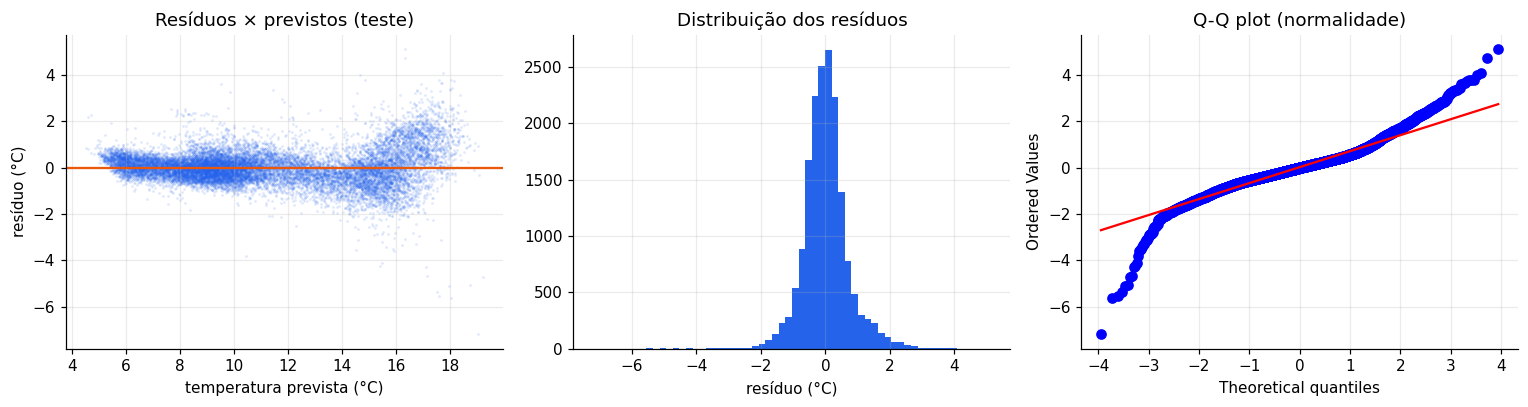

In [21]:
residuos_4 = y_teste - previsoes["4. Linear (15, com engenharia)"]
bp_p = het_breuschpagan(ols_4.resid, ols_4.model.exog)[1]
jb_p = jarque_bera(ols_4.resid)[1]
dw = durbin_watson(ols_4.resid)
print(f"Breusch-Pagan: p-valor = {bp_p:.3g}")
print(f"Jarque-Bera:   p-valor = {jb_p:.3g}")
print(f"Durbin-Watson: {dw:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].scatter(previsoes["4. Linear (15, com engenharia)"], residuos_4, s=3, alpha=0.15, color=AZUL, linewidths=0)
axes[0].axhline(0, color=LARANJA, linewidth=1.5)
axes[0].set(title="Resíduos × previstos (teste)", xlabel="temperatura prevista (°C)", ylabel="resíduo (°C)")
axes[1].hist(residuos_4, bins=60, color=AZUL)
axes[1].set(title="Distribuição dos resíduos", xlabel="resíduo (°C)")
stats.probplot(residuos_4, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot (normalidade)")
plt.tight_layout(); plt.savefig(FIGURAS / "residuos_linear.png", bbox_inches="tight"); plt.show()

**Interpretação.**

- **Breusch-Pagan (p ≈ 0):** rejeitamos a variância constante → há **heterocedasticidade**. No gráfico, os erros "abrem" nas águas
  quentes (superfície), onde a temperatura depende de sol, vento e estação, efeitos que uma reta não captura.
- **Jarque-Bera (p ≈ 0):** os resíduos **não são normais**. O Q-Q plot mostra caudas pesadas: algumas medições com erros grandes.
- **Durbin-Watson = 0,37** (bem abaixo de 2): forte **autocorrelação**. Medições vizinhas da mesma estação têm erros parecidos.
  Isso confirma que as observações **não são independentes** e justifica a divisão treino/teste **por estação**.

**Consequência:** as previsões e o R² continuam válidos, mas os **p-valores e intervalos de confiança** das tabelas do `statsmodels`
são otimistas e devem ser lidos com cautela. Os pressupostos violados também indicam que a relação **não é linear**, um motivo
a mais para a Parte B.

### 9.6 Modelo 5 — Regularização: Ridge e Lasso

**O que é.** Regressões lineares com uma **penalidade** sobre o tamanho dos coeficientes:

- **Ridge (L2):** penaliza $\sum \beta_j^2$, ou seja, encolhe os coeficientes, mas não os zera. Indicada para multicolinearidade.
- **Lasso (L1):** penaliza $\sum |\beta_j|$ e pode **zerar** coeficientes (seleciona variáveis).

A força da penalidade ($\alpha$) é escolhida por validação cruzada. As variáveis são **padronizadas** (média 0, desvio 1)
dentro de um `Pipeline`, para que a penalidade trate todas igualmente e o padronizador seja ajustado só no treino de cada dobra.

In [22]:
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25)))
display(avaliar("5a. Ridge (15)", ridge, COMPLETAS))
lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=SEED))
display(avaliar("5b. Lasso (15)", lasso, COMPLETAS))
print(f"alpha escolhido — Ridge: {ridge[-1].alpha_:.3g} | Lasso: {lasso[-1].alpha_:.3g} | coeficientes zerados pelo Lasso: {(lasso[-1].coef_ == 0).sum()}")

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
5a. Ridge (15),15,0.961,0.9609,0.0012,0.9618,0.9617,0.5035,0.7069


,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
5b. Lasso (15),15,0.9607,0.9606,0.0011,0.9614,0.9614,0.5005,0.7103


alpha escolhido — Ridge: 0.1 | Lasso: 0.00339 | coeficientes zerados pelo Lasso: 3


**Interpretação.** Ridge e Lasso dão **o mesmo R² da regressão linear comum** (0,962), e a validação cruzada escolhe
penalidades quase nulas. Isso é esperado: a regularização ajuda quando há **poucas observações e muitas variáveis** (risco de
overfitting). Aqui temos ~70 mil observações e 15 variáveis, e o modelo linear não tem overfitting nenhum.

**Decisão:** ferramenta **testada e descartada** como modelo de previsão, por não trazer ganho. (O Lasso volta na seção 9.8 como
ferramenta de **seleção de variáveis**.)

### 9.7 Modelo 6 — Regressão polinomial de grau 2

**O que é.** Ainda é uma regressão linear, mas sobre variáveis **transformadas**: além das 15 originais, entram todos os
**quadrados** ($x_1^2$) e todos os **produtos dois a dois** ($x_1 \cdot x_2$, as *interações*). Isso permite curvas e efeitos
combinados. São $15 + 15 \cdot 16/2 = 135$ termos, então aqui o **R² ajustado** usa $p = 135$.

In [23]:
polinomial = make_pipeline(StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
polinomial.fit(X_treino[COMPLETAS], y_treino)
n_termos = polinomial[1].n_output_features_
avaliar("6. Polinomial grau 2 (15 → 135 termos)", polinomial, COMPLETAS, p=n_termos)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
6. Polinomial grau 2 (15 → 135 termos),135,0.9866,0.986,0.001,0.9851,0.985,0.2709,0.4411


**Interpretação.** R² sobe para **0,985** e o erro cai para **0,27 °C**: as curvas e interações importam muito.
Mesmo com a penalidade de 135 termos, o R² ajustado (0,985) continua alto, porque $n$ é grande.

Mas o modelo perde o que a regressão linear tinha de melhor: com 135 coeficientes (como "salinidade × nitrato"), ele **não é mais interpretável**.
Se é para abrir mão da interpretação, vale testar modelos feitos para relações não lineares (Parte B).

**Decisão:** mantido como **referência** de que a não linearidade é o que falta ao modelo linear.

### 9.8 Seleção de variáveis para o modelo linear

O Modelo 4 tem 15 variáveis muito correlacionadas entre si. Quais realmente importam? Comparamos **dois métodos**:

1. **Caminho do Lasso:** com penalidade muito alta, nenhuma variável entra. Diminuindo a penalidade aos poucos, as variáveis
   entram uma de cada vez. A **ordem de entrada** vira um ranking.
2. **Seleção sequencial para frente (*forward selection*):** começa sem variáveis e, a cada passo, adiciona **a variável que mais aumenta
   o R² da validação cruzada**. É mais lenta, mas mede diretamente o que nos interessa (o R²).

Ambos usam **somente o treino**.

In [24]:
# Método 1 — ordem de entrada no caminho do Lasso (variáveis padronizadas)
Z_treino = StandardScaler().fit_transform(X_treino[COMPLETAS])
alphas, coefs, _ = lasso_path(Z_treino, y_treino - y_treino.mean(), n_alphas=200)
ordem_lasso = []
for i in range(len(alphas)):
    for j in np.flatnonzero(coefs[:, i]):
        if COMPLETAS[j] not in ordem_lasso:
            ordem_lasso.append(COMPLETAS[j])
ordem_lasso += [c for c in COMPLETAS if c not in ordem_lasso]

# Método 2 — seleção sequencial para frente (a cada passo, a variável que mais aumenta o R² da validação cruzada)
ordem_forward, curva_forward = [], []
restantes = list(COMPLETAS)
while restantes:
    notas = {c: cross_val_score(LinearRegression(), X_treino[ordem_forward + [c]], y_treino, cv=dobras, scoring="r2").mean() for c in restantes}
    melhor = max(notas, key=notas.get)
    ordem_forward.append(melhor); restantes.remove(melhor); curva_forward.append(notas[melhor])

curva_lasso = [cross_val_score(LinearRegression(), X_treino[ordem_lasso[:k]], y_treino, cv=dobras, scoring="r2").mean() for k in range(1, len(COMPLETAS) + 1)]
pd.DataFrame({"Lasso": ordem_lasso, "Forward": ordem_forward}, index=range(1, len(COMPLETAS) + 1)).T

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Lasso,NO3uM,log_prof,mes_sin,NO2uM,Lon_Dec,Lat_Dec,Year,Salnty,PO4uM,O2ml_L,Depthm,mes_cos,SiO3uM,Bottom_D,Distance
Forward,NO3uM,O2ml_L,PO4uM,log_prof,mes_sin,Salnty,NO2uM,mes_cos,Year,Depthm,SiO3uM,Lat_Dec,Distance,Lon_Dec,Bottom_D


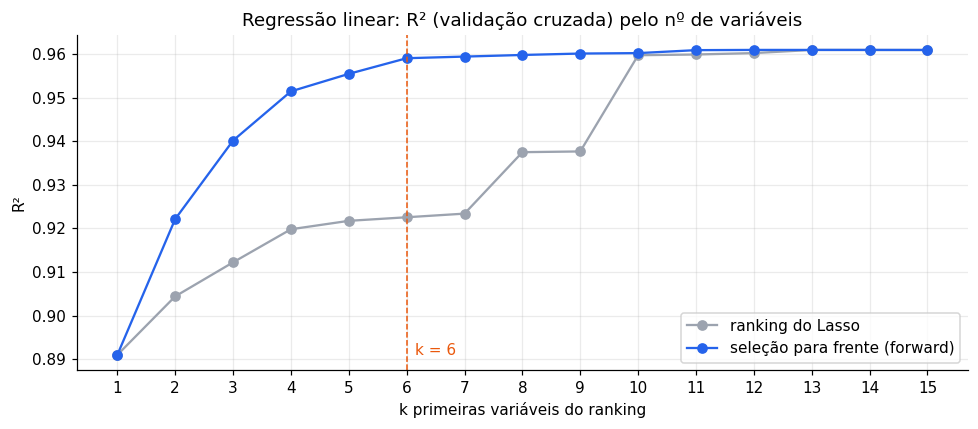

k escolhido: 6 -> ['NO3uM', 'O2ml_L', 'PO4uM', 'log_prof', 'mes_sin', 'Salnty']


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Lasso,0.891,0.904,0.912,0.920,0.922,0.923,0.923,0.937,0.938,0.96,0.960,0.960,0.961,0.961,0.961
Forward,0.891,0.922,0.940,0.951,0.955,0.959,0.959,0.960,0.960,0.96,0.961,0.961,0.961,0.961,0.961


In [25]:
TOLERANCIA = 0.005  # regra da parcimônia: o menor k cujo R² fica a no máximo 0,005 do melhor
ks = np.arange(1, len(COMPLETAS) + 1)
K_LIN = int(ks[np.array(curva_forward) >= max(curva_forward) - TOLERANCIA][0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, curva_lasso, "o-", color=CINZA, label="ranking do Lasso")
ax.plot(ks, curva_forward, "o-", color=AZUL, label="seleção para frente (forward)")
ax.axvline(K_LIN, color=LARANJA, linestyle="--", linewidth=1)
ax.text(K_LIN + 0.15, min(curva_lasso), f"k = {K_LIN}", color=LARANJA)
ax.set(title="Regressão linear: R² (validação cruzada) pelo nº de variáveis", xlabel="k primeiras variáveis do ranking", ylabel="R²", xticks=ks)
ax.legend(); plt.tight_layout(); plt.savefig(FIGURAS / "selecao_linear.png", bbox_inches="tight"); plt.show()

SEL_LIN = ordem_forward[:K_LIN]
print(f"k escolhido: {K_LIN} -> {SEL_LIN}")
pd.DataFrame({"Lasso": curva_lasso, "Forward": curva_forward}, index=ks).round(3).T

**Interpretação.**

- A seleção **para frente fica acima do Lasso em quase todos os pontos**. Com variáveis muito correlacionadas, o caminho do Lasso
  é instável: ele escolhe uma variável de cada grupo correlacionado quase "ao acaso", e nem sempre a mais útil.
  Com 6 variáveis, o ranking do Lasso chega a R² 0,923 e o da seleção para frente a **0,959**. O Lasso coloca na frente variáveis pouco úteis (latitude, longitude, ano) e deixa oxigênio e fosfato para o fim.
- **Decisão:** usamos a seleção **para frente**, que é a ferramenta adequada para este caso. O Lasso foi testado e descartado também como selecionador.
- **Regra da parcimônia:** escolhemos o **menor k** cujo R² fica a no máximo 0,005 do melhor → **k = 6**.

**As 6 variáveis escolhidas e o que representam:**

| # | Variável | O que representa |
|---|---|---|
| 1 | `NO3uM` (nitrato) | Sozinho já dá R² 0,89: "denuncia" a camada da água (muito nitrato = água funda e fria) |
| 2 | `O2ml_L` (oxigênio) | Água da superfície tem mais oxigênio (contato com o ar e algas) |
| 3 | `PO4uM` (fosfato) | Outro nutriente: complementa o nitrato nas camadas intermediárias |
| 4 | `log_prof` (log da profundidade) | A profundidade **transformada** entrou, e não a original: a engenharia de atributos funcionou |
| 5 | `mes_sin` (mês, cíclico) | Estação do ano: a superfície esquenta no verão |
| 6 | `Salnty` (salinidade) | Distingue massas de água de origens diferentes (a pergunta da base!) |

### 9.9 Modelo 7 — Regressão linear reduzida

In [26]:
ols_7 = sm.OLS(y_treino, sm.add_constant(X_treino[SEL_LIN])).fit()
print(ols_7.summary().tables[1])
avaliar(f"7. Linear reduzida ({K_LIN})", LinearRegression(), SEL_LIN)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -23.2890      0.695    -33.491      0.000     -24.652     -21.926
NO3uM         -0.1831      0.002   -105.766      0.000      -0.186      -0.180
O2ml_L        -1.9191      0.009   -219.381      0.000      -1.936      -1.902
PO4uM         -4.7633      0.031   -155.211      0.000      -4.823      -4.703
log_prof      -0.3648      0.003   -112.130      0.000      -0.371      -0.358
mes_sin       -0.3399      0.004    -84.381      0.000      -0.348      -0.332
Salnty         1.5852      0.020     78.743      0.000       1.546       1.625


,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
7. Linear reduzida (6),6,0.9591,0.959,0.001,0.9592,0.9592,0.5107,0.7305


**Interpretação.** Com 6 variáveis, R² **0,959** (contra 0,962 com 15) e erro de **0,51 °C**. É o melhor
compromisso entre desempenho e simplicidade entre os modelos lineares: cabe numa equação com 6 coeficientes, todos significativos.

**Fim da Parte A.** O teto linear "interpretável" fica perto de 0,96. A polinomial mostrou que o que falta é **não linearidade**,
e os testes de pressupostos confirmaram isso. Vamos aos modelos não lineares.

## 10. Parte B — Modelos não lineares

| Modelo | Ideia | Pergunta |
|---|---|---|
| 8. KNN | Prevê pela média dos vizinhos mais parecidos | Um método simples, baseado em distância, já resolve? |
| 9. Random Forest | Média de muitas árvores independentes | Árvores capturam a não linearidade? |
| 10. Gradient Boosting | Árvores em sequência, cada uma corrigindo a anterior | O método mais forte para dados tabulares é melhor? |
| 11. Gradient Boosting reduzido | Variáveis selecionadas para o próprio modelo | Dá para simplificar? |
| 12. Gradient Boosting ajustado | Hiperparâmetros escolhidos por busca em grade | Ajustar a configuração compensa? |

Todos usam o conjunto **completo de 15 variáveis**, para comparar só o algoritmo.

### 10.1 Modelo 8 — KNN (k vizinhos mais próximos)

**O que é.** Para prever uma medição, o KNN procura as $k$ medições **mais parecidas** no treino e tira a média das suas temperaturas.
Como "parecido" é medido por distância, as variáveis precisam estar na **mesma escala** (padronização dentro do Pipeline).
O número de vizinhos é escolhido por validação cruzada.

In [27]:
busca_knn = GridSearchCV(make_pipeline(StandardScaler(), KNeighborsRegressor()), {"kneighborsregressor__n_neighbors": [5, 10, 20, 40]}, cv=dobras, scoring="r2")
busca_knn.fit(X_treino[COMPLETAS], y_treino)
print("Vizinhos escolhidos:", busca_knn.best_params_["kneighborsregressor__n_neighbors"])
avaliar("8. KNN (15)", busca_knn.best_estimator_, COMPLETAS)

Vizinhos escolhidos: 10


,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
8. KNN (15),15,0.9892,0.9799,0.0007,0.9811,0.9811,0.3413,0.4964


**Interpretação.** O KNN chega a R² **0,981** (erro 0,34 °C), acima de todos os lineares interpretáveis, sem supor
nenhuma forma de relação. Mas trata todas as variáveis com o mesmo peso na distância, mesmo as pouco úteis (como latitude),
e é lento para prever (compara cada medição nova com todo o treino).

### 10.2 Modelo 9 — Random Forest

**O que é.** Uma "floresta" de 100 **árvores de decisão**. Cada árvore é um fluxograma de perguntas ("a profundidade é maior que 150 m?")
treinado numa amostra diferente dos dados, e a previsão final é a **média** das árvores. Árvores capturam curvas e interações naturalmente.

In [28]:
avaliar("9. Random Forest (15)", RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED), COMPLETAS)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
9. Random Forest (15),15,0.9994,0.9923,0.0006,0.9928,0.9928,0.1798,0.3063


**Interpretação.** R² **0,993** e erro de **0,18 °C**: as árvores resolvem a não linearidade. O R² de treino (0,999)
é bem maior que o de teste: a Random Forest **memoriza** parte do treino (cada árvore cresce até o fim). Ainda assim,
validação cruzada e teste coincidem, então o desempenho em dados novos é real.

### 10.3 Modelo 10 — Gradient Boosting

**O que é.** Também usa árvores, mas **em sequência**: a 1ª árvore faz uma previsão grosseira, a 2ª aprende a corrigir os erros da 1ª,
a 3ª corrige o que sobrou, e assim por diante (100 árvores no padrão). Usamos o `HistGradientBoostingRegressor`, versão rápida do
scikit-learn, com hiperparâmetros padrão.

In [29]:
avaliar("10. Gradient Boosting (15)", HistGradientBoostingRegressor(random_state=SEED), COMPLETAS)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
10. Gradient Boosting (15),15,0.9944,0.9925,0.0006,0.9928,0.9928,0.1992,0.3066


**Interpretação.** R² **0,993** e erro de **0,20 °C**, praticamente empatado com a Random Forest, mas com R² de treino
(0,994) muito mais próximo do teste: **menos overfitting**. Também é bem mais rápido para treinar e menor para guardar.
Seguimos com o Gradient Boosting.

### 10.4 Seleção de variáveis para o Gradient Boosting

O ranking da Parte A foi feito com um modelo **linear**: não é a melhor ordem para um modelo de árvores. Aqui o ranking é feito
pelo **próprio Gradient Boosting**, com a **importância por permutação**: embaralha-se uma variável por vez e mede-se quanto o R² cai.

Para não usar o teste, separamos 20% do **treino** (por estação) como validação interna só para calcular o ranking.
Depois, a mesma curva "R² × número de variáveis" e a mesma regra da parcimônia (tolerância de 0,005).

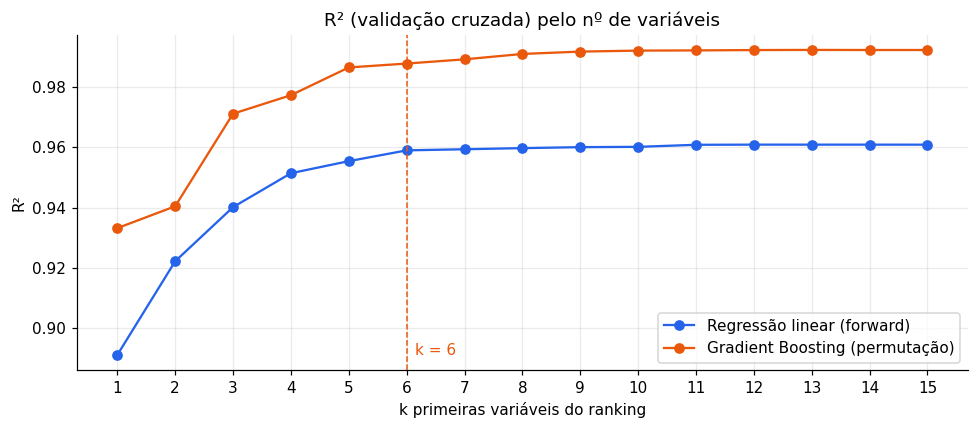

Ranking do Gradient Boosting: ['NO3uM', 'SiO3uM', 'O2ml_L', 'Depthm', 'mes_sin', 'PO4uM', 'Salnty', 'Year', 'Lon_Dec', 'mes_cos', 'Distance', 'NO2uM', 'Lat_Dec', 'Bottom_D', 'log_prof']
k escolhido: 6 -> ['NO3uM', 'SiO3uM', 'O2ml_L', 'Depthm', 'mes_sin', 'PO4uM']


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
R² CV,0.9332,0.9404,0.9712,0.9773,0.9866,0.9878,0.9892,0.991,0.9918,0.9921,0.9922,0.9923,0.9924,0.9923,0.9923


In [30]:
i_a, i_v = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED).split(X_treino, y_treino, grupos_treino))
gb_ranking = HistGradientBoostingRegressor(random_state=SEED).fit(X_treino.iloc[i_a][COMPLETAS], y_treino.iloc[i_a])
perm = permutation_importance(gb_ranking, X_treino.iloc[i_v][COMPLETAS], y_treino.iloc[i_v], n_repeats=5, random_state=SEED, scoring="r2")
ordem_gb = list(pd.Series(perm.importances_mean, index=COMPLETAS).sort_values(ascending=False).index)

dobras_3 = list(GroupKFold(n_splits=3).split(X_treino, y_treino, grupos_treino))  # 3 dobras para economizar tempo
curva_gb = [cross_val_score(HistGradientBoostingRegressor(random_state=SEED), X_treino[ordem_gb[:k]], y_treino, cv=dobras_3, scoring="r2").mean() for k in ks]
K_GB = int(ks[np.array(curva_gb) >= max(curva_gb) - TOLERANCIA][0])
SEL_GB = ordem_gb[:K_GB]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, curva_forward, "o-", color=AZUL, label="Regressão linear (forward)")
ax.plot(ks, curva_gb, "o-", color=LARANJA, label="Gradient Boosting (permutação)")
ax.axvline(K_GB, color=LARANJA, linestyle="--", linewidth=1)
ax.text(K_GB + 0.15, min(curva_forward), f"k = {K_GB}", color=LARANJA)
ax.set(title="R² (validação cruzada) pelo nº de variáveis", xlabel="k primeiras variáveis do ranking", ylabel="R²", xticks=ks)
ax.legend(); plt.tight_layout(); plt.savefig(FIGURAS / "curva_numero_variaveis.png", bbox_inches="tight"); plt.show()

print(f"Ranking do Gradient Boosting: {ordem_gb}")
print(f"k escolhido: {K_GB} -> {SEL_GB}")
pd.Series(curva_gb, index=ks, name="R² CV").round(4).to_frame().T

**Interpretação.**

- O Gradient Boosting fica **acima da regressão linear em todos os pontos**: com qualquer número de variáveis, o modelo não linear aproveita melhor a informação.
- A curva sobe rápido até 5–6 variáveis (0,988 com 6) e depois quase não muda: de 6 para 15 variáveis o ganho é de apenas ~0,005.
- Pela regra da parcimônia, **k = 6**.

**As 6 variáveis escolhidas para o Gradient Boosting:**

| # | Variável | O que representa |
|---|---|---|
| 1 | `NO3uM` (nitrato) | A variável mais importante, como no modelo linear |
| 2 | `SiO3uM` (silicato) | Nutriente que aumenta muito no fundo; separa bem as camadas profundas |
| 3 | `O2ml_L` (oxigênio) | Alto na superfície, baixo no fundo |
| 4 | `Depthm` (profundidade) | A profundidade **original**: para árvores, o log não faz diferença (a ordem dos valores é a mesma) |
| 5 | `mes_sin` (mês, cíclico) | Estação do ano |
| 6 | `PO4uM` (fosfato) | Complementa os outros nutrientes |

### 10.5 Modelo 11 — Gradient Boosting reduzido

In [31]:
avaliar(f"11. Gradient Boosting reduzido ({K_GB})", HistGradientBoostingRegressor(random_state=SEED), SEL_GB)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
11. Gradient Boosting reduzido (6),6,0.9901,0.988,0.0005,0.9886,0.9886,0.2407,0.3861


**Interpretação.** Com 6 variáveis, R² **0,989** (contra 0,993 com 15) e erro de **0,24 °C**.
Com menos da metade das variáveis, perde só ~0,004 de R². Salinidade, ano e localização ficaram de fora: para o modelo de árvores, a informação delas já está contida nos nutrientes e no oxigênio.

### 10.6 Modelo 12 — Gradient Boosting reduzido com ajuste de hiperparâmetros

**Hiperparâmetros** são configurações escolhidas **antes** do treino (os *parâmetros*, como os limites de corte das árvores, o modelo aprende sozinho).
Testamos todas as combinações abaixo (**busca em grade**, `GridSearchCV`), com validação cruzada de 3 dobras por estação, e ficamos com a melhor:

| Hiperparâmetro | O que controla | Valores testados |
|---|---|---|
| `learning_rate` | Quanto cada árvore corrige da anterior (menor = mais cuidadoso, precisa de mais árvores) | 0,05 e 0,1 |
| `max_iter` | Número de árvores | 300 e 800 |
| `max_leaf_nodes` | Tamanho máximo de cada árvore (complexidade) | 31 e 63 |

In [32]:
grade = {"learning_rate": [0.05, 0.1], "max_iter": [300, 800], "max_leaf_nodes": [31, 63]}
busca_gb = GridSearchCV(HistGradientBoostingRegressor(random_state=SEED), grade, cv=dobras_3, scoring="r2")
busca_gb.fit(X_treino[SEL_GB], y_treino)

tabela_busca = pd.DataFrame(busca_gb.cv_results_)[["params", "mean_test_score", "mean_fit_time"]].sort_values("mean_test_score", ascending=False)
display(tabela_busca.rename(columns={"mean_test_score": "R² CV", "mean_fit_time": "tempo (s)"}).round(4))
MELHORES = busca_gb.best_params_
print("Melhor combinação:", MELHORES)
avaliar(f"12. Gradient Boosting ajustado ({K_GB})", HistGradientBoostingRegressor(random_state=SEED, **MELHORES), SEL_GB)

,params,R² CV,tempo (s)
3,"{'learning_rate': 0.05, 'max_iter': 800, 'max_...",0.9888,321.6256
1,"{'learning_rate': 0.05, 'max_iter': 300, 'max_...",0.9888,1.6052
2,"{'learning_rate': 0.05, 'max_iter': 800, 'max_...",0.9888,314.0406
5,"{'learning_rate': 0.1, 'max_iter': 300, 'max_l...",0.9887,6.0432
6,"{'learning_rate': 0.1, 'max_iter': 800, 'max_l...",0.9887,1.7338
4,"{'learning_rate': 0.1, 'max_iter': 300, 'max_l...",0.9886,4.3701
7,"{'learning_rate': 0.1, 'max_iter': 800, 'max_l...",0.9885,319.0008
0,"{'learning_rate': 0.05, 'max_iter': 300, 'max_...",0.9883,4.2234


Melhor combinação: {'learning_rate': 0.05, 'max_iter': 800, 'max_leaf_nodes': 63}


,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
12. Gradient Boosting ajustado (6),6,0.9946,0.9891,0.0003,0.9896,0.9896,0.2214,0.369


**Interpretação.** O ajuste leva o R² de 0,989 para **0,990** e o erro de 0,24 para **0,22 °C**.
A melhor combinação usa taxa de aprendizado 0,05, 800 árvores e até 63 folhas por árvore. O ganho é **pequeno**: as 8 combinações ficaram entre 0,988 e 0,989 na validação cruzada, o que mostra que os valores padrão já eram adequados e que o modelo é pouco sensível aos hiperparâmetros. Mais árvores e árvores maiores capturam detalhes finos, e a validação cruzada garante
que isso não é overfitting: o R² de treino (0,995) segue próximo do de validação cruzada (0,989) e do de teste.

## 11. Comparação de todos os modelos

In [33]:
tabela = pd.DataFrame(resultados).set_index("modelo")
tabela.round(4)

,nº variáveis,R² treino,R² validação cruzada,desvio CV,R² teste,R² ajustado teste,MAE teste (°C),RMSE teste (°C)
modelo,,,,,,,,
0. Baseline (média),0,0.0000,-0.0001,0.0000,-0.0002,-0.0002,3.0511,3.6156
1. Linear (salinidade),1,0.6496,0.6495,0.0057,0.6332,0.6332,1.5793,2.1894
2. Linear (salinidade + profundidade),2,0.7425,0.7424,0.0045,0.7307,0.7306,1.4438,1.8762
3. Linear (13 originais),13,0.9575,0.9573,0.0005,0.9584,0.9584,0.5259,0.7372
"4. Linear (15, com engenharia)",15,0.9610,0.9609,0.0012,0.9618,0.9617,0.5035,0.7069
5a. Ridge (15),15,0.9610,0.9609,0.0012,0.9618,0.9617,0.5035,0.7069
5b. Lasso (15),15,0.9607,0.9606,0.0011,0.9614,0.9614,0.5005,0.7103
6. Polinomial grau 2 (15 → 135 termos),135,0.9866,0.9860,0.0010,0.9851,0.9850,0.2709,0.4411
7. Linear reduzida (6),6,0.9591,0.9590,0.0010,0.9592,0.9592,0.5107,0.7305


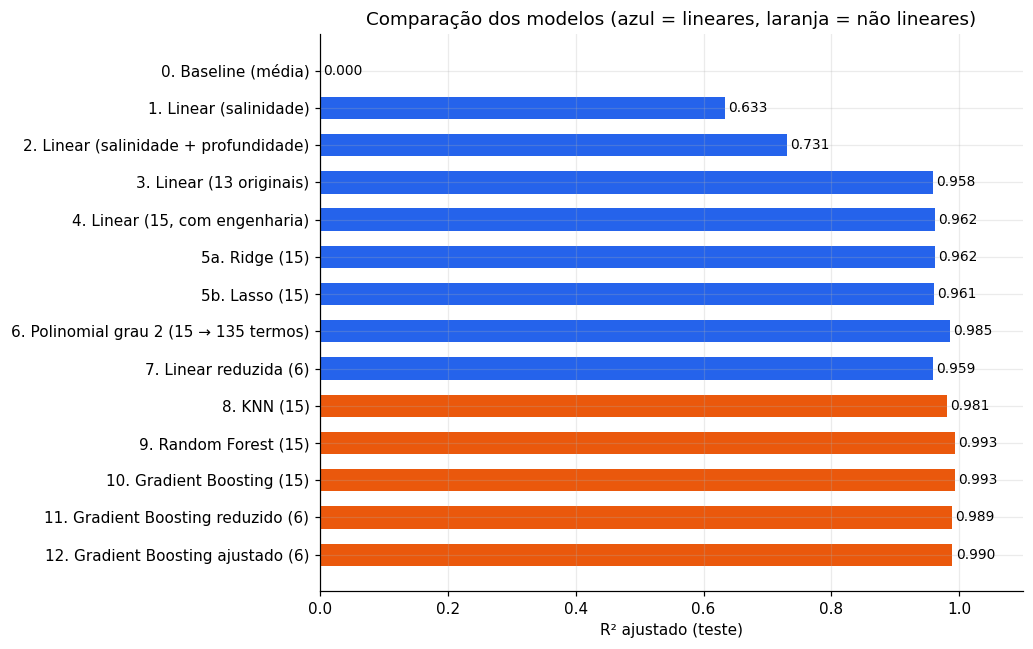

In [34]:
fig, ax = plt.subplots(figsize=(9.5, 6))
nomes = tabela.index[::-1]
valores = tabela.loc[nomes, "R² ajustado teste"].clip(lower=0)
lineares = ("0.", "1.", "2.", "3.", "4.", "5", "6.", "7.")
cores = [AZUL if n.startswith(lineares) else LARANJA for n in nomes]
ax.barh(nomes, valores, color=cores, height=0.6)
for i, v in enumerate(valores):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set(xlim=(0, 1.1), xlabel="R² ajustado (teste)", title="Comparação dos modelos (azul = lineares, laranja = não lineares)")
plt.tight_layout(); plt.savefig(FIGURAS / "comparacao_modelos.png", bbox_inches="tight"); plt.show()

### Ferramentas testadas: o que ficou e o que saiu

| Etapa | Ferramenta | Resultado | Decisão |
|---|---|---|---|
| Referência | Baseline (média) | R² ≈ 0 | Referência mínima |
| Modelo linear | Regressão linear (OLS) | até 0,962 | **Mantida** como modelo interpretável |
| Transformação | Engenharia de atributos (log, seno/cosseno) | +0,004 no linear | **Mantida** (o `log_prof` foi escolhido pela seleção) |
| Regularização | Ridge e Lasso | = linear comum (0,962) | **Descartados**: sem overfitting para corrigir ($n \gg p$) |
| Não linearidade | Polinomial de grau 2 | 0,985 com 135 termos | **Referência**: prova a não linearidade, mas não é interpretável |
| Seleção (linear) | Caminho do Lasso | 0,923 com 6 variáveis | **Descartado**: instável com multicolinearidade |
| Seleção (linear) | Seleção para frente | 0,959 com 6 variáveis | **Mantida** |
| Não linear | KNN | 0,981 | **Descartado**: abaixo das árvores e lento para prever |
| Não linear | Random Forest | 0,993 | **Descartado**: empata com o Gradient Boosting, mas memoriza o treino (R² treino 0,999) e é mais pesado |
| Não linear | Gradient Boosting | 0,993 | **Mantido** |
| Seleção (árvores) | Importância por permutação + curva | 6 variáveis, 0,989 | **Mantida** |
| Ajuste | Busca em grade de hiperparâmetros | +0,001 | **Mantida** no modelo final (ganho pequeno, sem acrescentar variáveis) |

### Conclusões da comparação

1. **A pergunta da base:** só a salinidade explica ~63% da temperatura. Ajuda, mas não basta.
2. **As variáveis certas fazem a maior diferença:** no modelo linear, de 0,633 (salinidade) para 0,962 (15 variáveis).
3. **A relação é não linear:** os testes de pressupostos, a polinomial e todos os modelos de árvores mostram isso. Com as mesmas
   variáveis, o Gradient Boosting supera a regressão linear em todos os pontos da curva de seleção.
4. **R² × R² ajustado:** como $n$ (≈ 17.465 no teste) é muito maior que $p$, a penalidade é pequena. Ela só aparece de forma visível
   na polinomial (135 termos). Nenhum modelo "infla" o R² com variáveis inúteis.
5. **Estabilidade:** em todos os modelos, a validação cruzada ficou próxima do teste, com desvio pequeno.

## 12. Teste de robustez: o modelo funciona no "futuro"?

R² acima de 0,99 merece desconfiança: será que há vazamento escondido? Fazemos um teste mais difícil: **treinamos só com
2005–2013 e testamos em 2014–2016**, anos que o modelo nunca viu. O período inclui o **"Blob"**, uma onda de calor marinha
que deixou o Pacífico anormalmente quente em 2014–2015. (A variável `Year` sai, porque os anos de teste não existem no treino.)

In [35]:
SEL_SEM_ANO = [c for c in SEL_GB if c != "Year"]
LIN_SEM_ANO = [c for c in SEL_LIN if c != "Year"]
base_robustez = pd.concat([treino, teste])
passado, futuro = base_robustez[base_robustez["Year"] <= 2013], base_robustez[base_robustez["Year"] >= 2014]

robustez = []
for nome, modelo, cols in [
    (f"Linear reduzida ({len(LIN_SEM_ANO)})", LinearRegression(), LIN_SEM_ANO),
    (f"Gradient Boosting ajustado ({len(SEL_SEM_ANO)})", HistGradientBoostingRegressor(random_state=SEED, **MELHORES), SEL_SEM_ANO),
]:
    modelo.fit(passado[cols], passado[ALVO])
    pred = modelo.predict(futuro[cols])
    robustez.append({"modelo": nome, "R² em 2014-2016": r2_score(futuro[ALVO], pred), "MAE (°C)": mean_absolute_error(futuro[ALVO], pred)})
print(f"Treino: {len(passado):,} medições (2005-2013) | Teste: {len(futuro):,} medições (2014-2016)")
pd.DataFrame(robustez).set_index("modelo").round(3)

Treino: 67,271 medições (2005-2013) | Teste: 20,894 medições (2014-2016)


,R² em 2014-2016,MAE (°C)
modelo,,
Linear reduzida (6),0.950,0.593
Gradient Boosting ajustado (6),0.982,0.321


**Interpretação.** Prevendo anos que nunca viu, e anos anormalmente quentes, o Gradient Boosting mantém R² de **0,982**
(erro 0,32 °C). O resultado alto **não é vazamento**: é uma relação física real entre a temperatura e a "assinatura química" da água.

## 13. Diagnóstico do modelo final: onde ele erra?

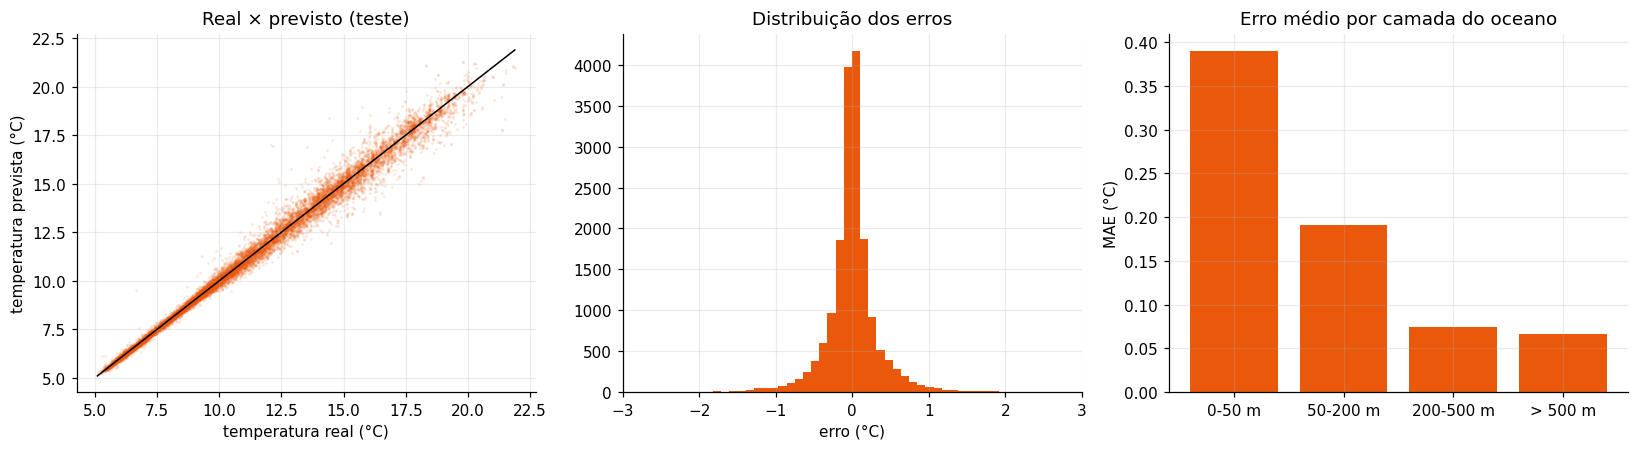

camada,0-50 m,50-200 m,200-500 m,> 500 m
medições,5702.00,6595.000,4636.000,532.000
MAE (°C),0.39,0.191,0.075,0.066


In [36]:
NOME_FINAL = f"12. Gradient Boosting ajustado ({K_GB})"
modelo_final, pred_final = modelos[NOME_FINAL], previsoes[NOME_FINAL]
erro_final = y_teste - pred_final

camadas = pd.cut(X_teste["Depthm"], [-1, 50, 200, 500, 10_000], labels=["0-50 m", "50-200 m", "200-500 m", "> 500 m"])
por_camada = pd.DataFrame({"erro": erro_final.abs(), "camada": camadas}).groupby("camada", observed=True)["erro"].agg(["count", "mean"])
por_camada.columns = ["medições", "MAE (°C)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
lim = [y_teste.min(), y_teste.max()]
axes[0].scatter(y_teste, pred_final, s=3, alpha=0.15, color=LARANJA, linewidths=0)
axes[0].plot(lim, lim, color="black", linewidth=1)
axes[0].set(title="Real × previsto (teste)", xlabel="temperatura real (°C)", ylabel="temperatura prevista (°C)")
axes[1].hist(erro_final, bins=80, color=LARANJA)
axes[1].set(title="Distribuição dos erros", xlabel="erro (°C)", xlim=(-3, 3))
axes[2].bar(por_camada.index.astype(str), por_camada["MAE (°C)"], color=LARANJA)
axes[2].set(title="Erro médio por camada do oceano", ylabel="MAE (°C)")
plt.tight_layout(); plt.savefig(FIGURAS / "modelo_final.png", bbox_inches="tight"); plt.show()
por_camada.round(3).T

**Interpretação.**

- Os pontos ficam colados à diagonal (previsto ≈ real) em toda a faixa de temperaturas.
- Os erros são centrados em zero e quase todos menores que 0,5 °C.
- O erro é maior na **superfície** (0–50 m: 0,39 °C) e cai com a profundidade (abaixo de 200 m: menos de 0,08 °C). Faz sentido: na superfície a temperatura varia com sol, vento e estação do ano, informações que o modelo só tem de forma indireta (pelo mês); no fundo, a água é estável.

## 14. Quais variáveis o modelo final mais usa?

Importância por permutação no **teste**: embaralhamos uma variável por vez e medimos quanto o R² cai.

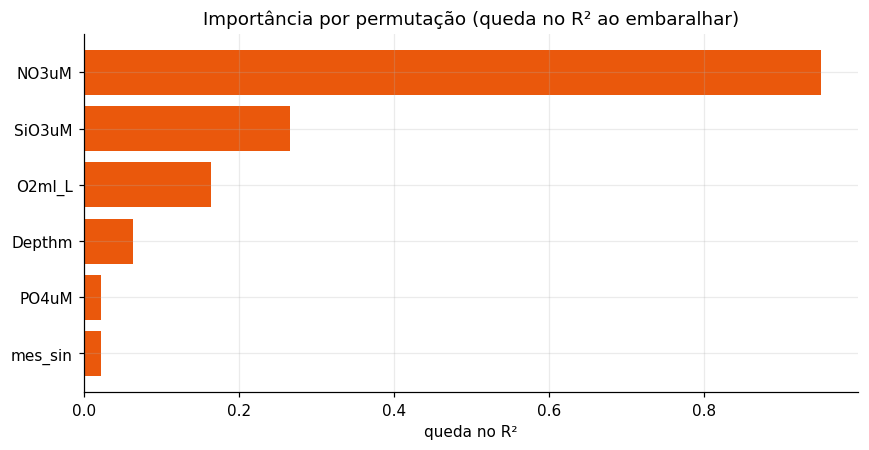

,NO3uM,SiO3uM,O2ml_L,Depthm,PO4uM,mes_sin
queda no R²,0.951,0.266,0.164,0.064,0.023,0.022


In [37]:
perm_final = permutation_importance(modelo_final, X_teste[SEL_GB], y_teste, n_repeats=5, random_state=SEED, scoring="r2")
importancia = pd.Series(perm_final.importances_mean, index=SEL_GB).sort_values()

fig, ax = plt.subplots(figsize=(8, 0.5 * len(SEL_GB) + 1.2))
ax.barh(importancia.index, importancia.values, color=LARANJA)
ax.set(title="Importância por permutação (queda no R² ao embaralhar)", xlabel="queda no R²")
plt.tight_layout(); plt.savefig(FIGURAS / "importancia_variaveis.png", bbox_inches="tight"); plt.show()
importancia.sort_values(ascending=False).round(3).to_frame("queda no R²").T

**Interpretação.** O modelo depende sobretudo do **nitrato** (embaralhá-lo derruba o R² em 0,95: sem ele o modelo praticamente não funciona), seguido de **silicato** (0,27), **oxigênio** (0,16), **profundidade** (0,06), **fosfato** e **mês** (0,02 cada). Leitura física: nutrientes e oxigênio identificam **de qual camada do oceano** a água veio, e o mês ajusta a temperatura da superfície conforme a **estação do ano**.

## 15. Modelo final

**O modelo escolhido é o Modelo 12: Gradient Boosting com 6 variáveis e hiperparâmetros ajustados.**

| Item | Definição |
|---|---|
| Problema | Regressão: prever a temperatura da água (`T_degC`, em °C) |
| Algoritmo | Gradient Boosting (`HistGradientBoostingRegressor`, scikit-learn) |
| Hiperparâmetros | `learning_rate=0.05`, `max_iter=800` (árvores), `max_leaf_nodes=63`, `random_state=42` |
| Variáveis (6) | `NO3uM` (nitrato), `SiO3uM` (silicato), `O2ml_L` (oxigênio), `Depthm` (profundidade), `mes_sin` (mês cíclico), `PO4uM` (fosfato) |
| Seleção das variáveis | Importância por permutação + curva de validação cruzada + regra da parcimônia |
| Dados | 70.700 medições de treino e 17.465 de teste (2005–2016), divididas por estação |
| R² treino | 0,995 |
| R² validação cruzada | 0,989 |
| R² teste | **0,990** |
| R² ajustado teste | **0,990** |
| MAE / RMSE teste | 0,22 °C / 0,37 °C |
| Teste temporal (2014–2016) | R² 0,982 |

**Por que este modelo** (aplicando o critério definido na seção 1):

1. O melhor R² de validação cruzada é o do Gradient Boosting com 15 variáveis (0,9925). O Modelo 12 fica a só **0,0034** dele,
   dentro da tolerância de 0,005, usando **6 variáveis em vez de 15**. Pela parcimônia, ficamos com o mais simples.
2. O custo da simplificação é pequeno: o erro médio passa de 0,20 para 0,22 °C.
3. As 6 variáveis têm explicação física clara (nutrientes, oxigênio, profundidade e estação do ano).
4. Treino, validação cruzada e teste próximos: **sem overfitting relevante**.
5. Passou no **teste de robustez temporal** (R² 0,982 em anos nunca vistos).

**Alternativas, se a prioridade for outra:**

| Prioridade | Modelo | R² ajustado |
|---|---|---|
| Uma equação que dá para escrever e interpretar | 7. Regressão linear reduzida (6 variáveis) | 0,959 |
| O maior R² possível, sem se importar com o nº de variáveis | 10. Gradient Boosting com 15 variáveis | 0,993 |
| Sem ajuste de hiperparâmetros | 11. Gradient Boosting reduzido, hiperparâmetros padrão | 0,989 |

## 16. O modelo na prática

A célula abaixo sorteia **uma medição do conjunto de teste** (que o modelo nunca viu), faz a previsão e compara com a temperatura real.
Cada execução sorteia uma medição diferente.

In [38]:
i = np.random.default_rng().choice(X_teste.index)
real, previsto = y_teste.loc[i], modelo_final.predict(X_teste.loc[[i], SEL_GB])[0]
linha = X_teste.loc[i]
print(f"Estação {int(linha['Cst_Cnt'])} | {int(linha['Month']):02d}/{int(linha['Year'])} | lat {linha['Lat_Dec']:.2f}, lon {linha['Lon_Dec']:.2f}")
print(f"Profundidade: {linha['Depthm']:.0f} m | salinidade: {linha['Salnty']:.2f} | oxigênio: {linha['O2ml_L']:.2f} ml/L | nitrato: {linha['NO3uM']:.1f} µmol/L")
print(f"\nTemperatura real:     {real:.2f} °C")
print(f"Temperatura prevista: {previsto:.2f} °C")
print(f"Erro:                 {previsto - real:+.2f} °C")

Estação 32876 | 10/2011 | lat 30.84, lon -121.59
Profundidade: 441 m | salinidade: 34.16 | oxigênio: 0.71 ml/L | nitrato: 39.7 µmol/L

Temperatura real:     5.95 °C
Temperatura prevista: 5.95 °C
Erro:                 -0.00 °C


## 17. Conclusões

- **Pergunta da base:** a salinidade sozinha prevê a temperatura só parcialmente (R² = 0,633, erro médio 1,58 °C).
- **Com as variáveis certas** (profundidade, oxigênio e nutrientes), o modelo linear chega a 0,962.
- **A relação é não linear:** os pressupostos da regressão linear são violados, e a polinomial e os modelos de árvores sobem muito.
- **Modelo final:** Gradient Boosting com 6 variáveis e hiperparâmetros ajustados, com **R² = 0,990** e erro médio de **0,22 °C**.
- **Por quê:** a temperatura do oceano não muda em linha reta com a profundidade (termoclina), e cada camada tem uma
  "assinatura química" (sal, oxigênio, nutrientes) que denuncia sua temperatura.
- **O resultado é confiável:** sem colunas de vazamento, com divisão por estação, outliers definidos só no treino, validação cruzada
  estável e teste em anos futuros.

## 18. Limitações

- **Recorte:** costa da Califórnia, 2005–2016. Para outros oceanos ou épocas, o modelo precisaria ser re-treinado.
- **Utilidade prática:** os nutrientes são medidos em laboratório. O modelo serve mais para **completar dados faltantes** ou
  **detectar medições suspeitas** do que para substituir o termômetro.
- **Busca de hiperparâmetros limitada:** testamos 8 combinações. Uma busca maior poderia melhorar um pouco, a um custo de tempo alto.
- **Regra da parcimônia:** a tolerância de 0,005 é uma escolha nossa. Outra tolerância mudaria o número de variáveis.
- **p-valores dos modelos lineares:** como os resíduos são heterocedásticos, não normais e autocorrelacionados, os p-valores do
  `statsmodels` são otimistas. Uma alternativa seria usar erros-padrão robustos (HC3) ou agrupados por estação.